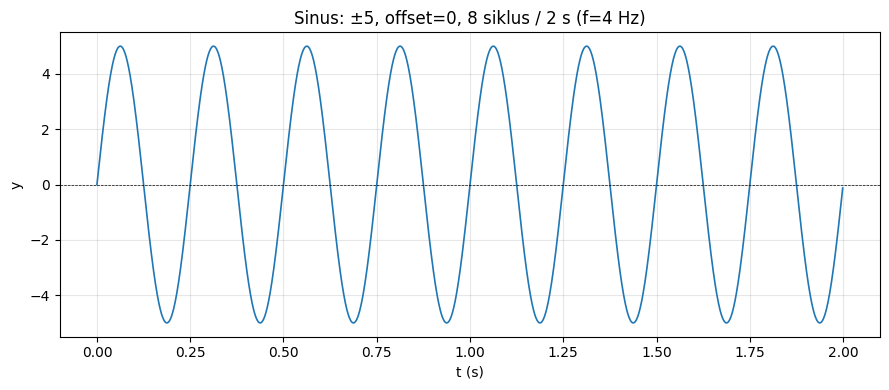

In [17]:
# cell 0
import numpy as np
import matplotlib.pyplot as plt

A = 5.0  # amplitudo puncak: y berkisar di [-A, +A]
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus penuh dalam [T]: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f = n_cycles / T  # Hz agar tepat n_cycles selama T

t = np.arange(0.0, T, 1.0 / fs)
y = A * np.sin(2 * np.pi * f * t)  # tanpa offset (DC = 0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, color="C0", lw=1.2)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(f"Sinus: ±{A:g}, offset=0, {n_cycles} siklus / {T:g} s (f={f:g} Hz)")
ax.set_ylim(-A * 1.1, A * 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

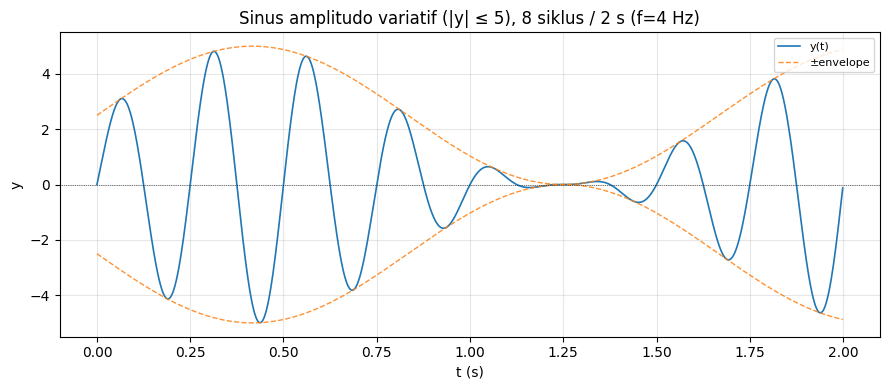

In [18]:
# cell 1
"""
Sinus amplitudo variatif — modulasi amplitudo (AM).

Idea:
- Carrier: sin(2*pi*f*t), nilai di [-1, 1].
- Envelope: (A_max/2) * (1 + sin(2*pi*f_env*t)), selalu di [0, A_max].
- Sinyal: y(t) = envelope(t) * carrier(t).

Batas |y| <= A_max:
Karena |carrier| <= 1, maka |y(t)| <= envelope(t) <= A_max.
Saat sin(...)=-1 envelope=0; saat sin(...)=+1 envelope=A_max.

Parameter:
- f_env: laju variasi amplop (Hz), biasanya lebih kecil dari f carrier.
- f, n_cycles, T, fs: sama konsepnya dengan sel 0 (jumlah siklus carrier dalam T).
"""

import numpy as np
import matplotlib.pyplot as plt

A_max = 5.0  # batas mutlak: |y(t)| tidak melebihi A_max
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus penuh dalam [T]: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f = n_cycles / T  # Hz agar tepat n_cycles selama T

t = np.arange(0.0, T, 1.0 / fs)
# Envelope amplitudo variatif dalam [0, A_max] → |envelope * sin| ≤ A_max
f_env = 0.6  # frekuensi modulasi amplitudo (Hz), lebih rendah dari carrier
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))
carrier = np.sin(2 * np.pi * f * t)
y = envelope * carrier  # tanpa offset DC pada carrier; envelope bermean >0 tapi y tetap |y|≤A_max

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, color="C0", lw=1.2, label="y(t)")
ax.plot(t, envelope, color="C1", lw=1.0, ls="--", alpha=0.85, label="±envelope")
ax.plot(t, -envelope, color="C1", lw=1.0, ls="--", alpha=0.85)
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(f"Sinus amplitudo variatif (|y| ≤ {A_max:g}), {n_cycles} siklus / {T:g} s (f={f:g} Hz)")
ax.set_ylim(-A_max * 1.1, A_max * 1.1)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

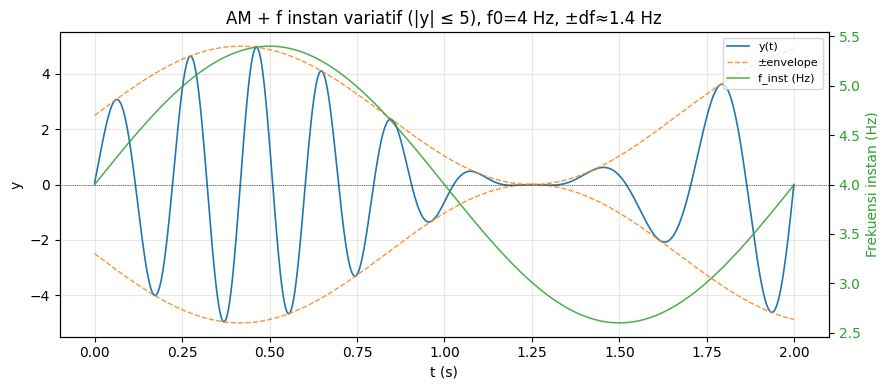

In [19]:
# cell 2
"""
AM + frekuensi instan variatif (FM lewat integrasi fasa).

- Amplitudo: envelope(t) di [0, A_max] seperti sel 1; y(t) = envelope(t) * carrier(t).
- Frekuensi instan: f_inst(t) = f0 + df * sin(2*pi*f_fm*t), dipotong ke f_min agar > 0.
- Fasa: phi = kumulatif sum(2*pi*f_inst*dt); carrier = sin(phi) (bukan sin(2*pi*f0*t)).

f0 = n_cycles/T sebagai pusat; df lebar ayunan Hz; f_fm laju modulasi frekuensi.
"""

import numpy as np
import matplotlib.pyplot as plt

A_max = 5.0  # batas mutlak: |y(t)| tidak melebihi A_max
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus rata-rata ~f0*T: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f0 = n_cycles / T  # pusat frekuensi instan (Hz)

dt = 1.0 / fs
t = np.arange(0.0, T, dt)

f_env = 0.6  # modulasi amplitudo (Hz)
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))

f_fm = 0.5  # modulasi frekuensi (Hz)
df = 0.35 * f0  # setengah-lebar ayunan frekuensi instan (Hz)
f_min = 0.15  # lantai Hz agar f_inst selalu positif
f_inst = f0 + df * np.sin(2 * np.pi * f_fm * t)
f_inst = np.clip(f_inst, f_min, None)

phi = np.cumsum(2 * np.pi * f_inst * dt)
carrier = np.sin(phi)
y = envelope * carrier

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y, color="C0", lw=1.2, label="y(t)")
ax.plot(t, envelope, color="C1", lw=1.0, ls="--", alpha=0.85, label="±envelope")
ax.plot(t, -envelope, color="C1", lw=1.0, ls="--", alpha=0.85)
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(
    f"AM + f instan variatif (|y| ≤ {A_max:g}), f0={f0:g} Hz, ±df≈{df:g} Hz"
)
ax.set_ylim(-A_max * 1.1, A_max * 1.1)

ax2 = ax.twinx()
ax2.plot(t, f_inst, color="C2", lw=1.1, alpha=0.85, label="f_inst (Hz)")
ax2.set_ylabel("Frekuensi instan (Hz)", color="C2")
ax2.tick_params(axis="y", labelcolor="C2")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

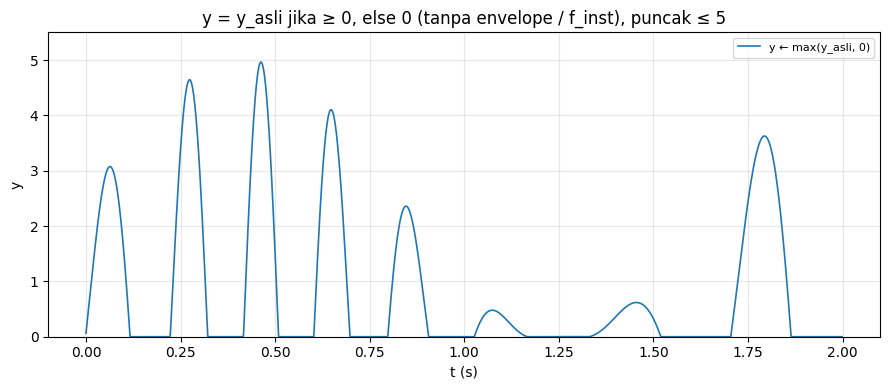

In [20]:
# cell 3
"""
Salinan logika sel sebelumnya (AM + f instan variatif).

Setelah y dihitung: jika y >= 0 pakai nilai asli, jika tidak y = 0
(setara np.maximum(y, 0) / half-wave ke nol). Tanpa envelope dan f_inst.
"""

import numpy as np
import matplotlib.pyplot as plt

A_max = 5.0  # batas mutlak: |y(t)| tidak melebihi A_max
T = 2.0  # durasi plot (s)
fs = 1000  # laju sampel (Hz)
n_cycles = 8  # jumlah siklus rata-rata ~f0*T: minimal 7, maksimal 10
n_cycles = int(np.clip(n_cycles, 7, 10))
f0 = n_cycles / T  # pusat frekuensi instan (Hz)

dt = 1.0 / fs
t = np.arange(0.0, T, dt)

f_env = 0.6  # modulasi amplitudo (Hz)
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))

f_fm = 0.5  # modulasi frekuensi (Hz)
df = 0.35 * f0  # setengah-lebar ayunan frekuensi instan (Hz)
f_min = 0.15  # lantai Hz agar f_inst selalu positif
f_inst = f0 + df * np.sin(2 * np.pi * f_fm * t)
f_inst = np.clip(f_inst, f_min, None)

phi = np.cumsum(2 * np.pi * f_inst * dt)
carrier = np.sin(phi)
y = envelope * carrier

y_plot = np.where(y >= 0, y, 0.0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y_plot, color="C0", lw=1.2, label="y ← max(y_asli, 0)")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title(f"y = y_asli jika ≥ 0, else 0 (tanpa envelope / f_inst), puncak ≤ {A_max:g}")
ax.set_ylim(0, A_max * 1.1)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TH=2.0, HY=±0.05 → naik ≥ 2.05, turun ≤ 1.95
Jumlah region terdeteksi: 6

Region 1: n_sampel=64, t ∈ [0.03200, 0.09500] s, puncak regional t=0.06400 s, y=3.0750, y_min=1.9169
Region 2: n_sampel=71, t ∈ [0.23900, 0.30900] s, puncak regional t=0.27400 s, y=4.6441, y_min=1.9169
Region 3: n_sampel=70, t ∈ [0.42900, 0.49800] s, puncak regional t=0.46300 s, y=4.9619, y_min=1.8110
Region 4: n_sampel=65, t ∈ [0.61800, 0.68200] s, puncak regional t=0.64800 s, y=4.1029, y_min=1.8683
Region 5: n_sampel=38, t ∈ [0.83000, 0.86700] s, puncak regional t=0.84600 s, y=2.3589, y_min=1.9442
Region 6: n_sampel=99, t ∈ [1.74300, 1.84100] s, puncak regional t=1.79400 s, y=3.6266, y_min=1.8931


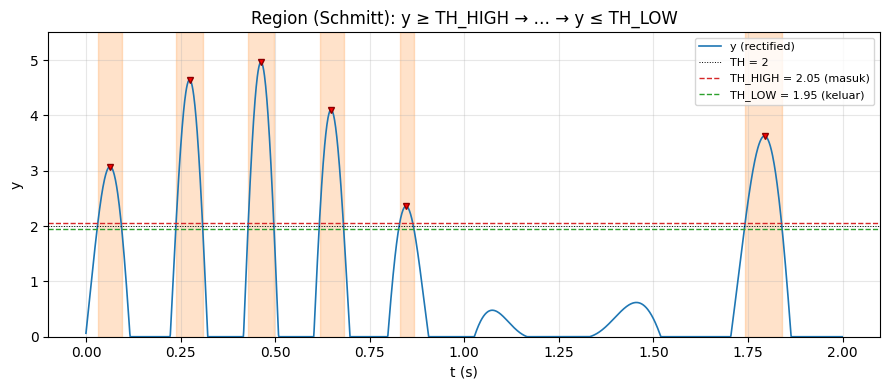

In [21]:
# cell 4
"""
Deteksi region (Schmitt trigger / hysteresis) pada sinyal y = max(y_asli, 0).

- Threshold referensi: 2.0
- Hysteresis: ±0.05 → masuk region saat y >= TH_HIGH (2.05), keluar saat y <= TH_LOW (1.95)
  (mirip komparator Schmitt: noise di sekitar 2 tidak memecah region berlebihan)

Per region: kumpulkan array t dan y untuk sampel dari crossing naik sampai crossing turun.
"""

import numpy as np
import matplotlib.pyplot as plt

# --- bangkit sinyal (sama seperti sel rectified / AM+FM) ---
A_max = 5.0
T = 2.0
fs = 1000
n_cycles = 8
n_cycles = int(np.clip(n_cycles, 7, 10))
f0 = n_cycles / T
dt = 1.0 / fs
t = np.arange(0.0, T, dt)

f_env = 0.6
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))
f_fm = 0.5
df = 0.35 * f0
f_min = 0.15
f_inst = np.clip(f0 + df * np.sin(2 * np.pi * f_fm * t), f_min, None)
phi = np.cumsum(2 * np.pi * f_inst * dt)
y = envelope * np.sin(phi)
y_sig = np.where(y >= 0, y, 0.0)

# --- Schmitt: pusat 2, hysteresis ±0.05 ---
TH = 2.0
HY = 0.05
TH_HIGH = TH + HY  # 2.05
TH_LOW = TH - HY  # 1.95

n = len(y_sig)
active = False
start_idx = 0
regions = []

if n > 0 and y_sig[0] >= TH_HIGH:
    active = True
    start_idx = 0

for i in range(n):
    yv = y_sig[i]
    if not active:
        if yv >= TH_HIGH:
            active = True
            start_idx = i
    else:
        if yv <= TH_LOW:
            regions.append(
                {
                    "i0": start_idx,
                    "i1": i,
                    "t": t[start_idx : i + 1].copy(),
                    "y": y_sig[start_idx : i + 1].copy(),
                }
            )
            active = False

if active:
    regions.append(
        {
            "i0": start_idx,
            "i1": n - 1,
            "t": t[start_idx:n].copy(),
            "y": y_sig[start_idx:n].copy(),
        }
    )

print(f"TH={TH}, HY=±{HY} → naik ≥ {TH_HIGH}, turun ≤ {TH_LOW}")
print(f"Jumlah region terdeteksi: {len(regions)}\n")
for k, r in enumerate(regions, start=1):
    j = int(np.argmax(r["y"]))
    t_pk = float(r["t"][j])
    y_pk = float(r["y"][j])
    print(
        f"Region {k}: n_sampel={len(r['y'])}, "
        f"t ∈ [{r['t'][0]:.5f}, {r['t'][-1]:.5f}] s, "
        f"puncak regional t={t_pk:.5f} s, y={y_pk:.4f}, "
        f"y_min={r['y'].min():.4f}"
    )

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, y_sig, color="C0", lw=1.2, label="y (rectified)")
for r in regions:
    ax.axvspan(r["t"][0], r["t"][-1], alpha=0.22, color="C1", label="_nolegend_")
for r in regions:
    j = int(np.argmax(r["y"]))
    ax.plot(r["t"][j], r["y"][j], "rv", ms=5, mfc="red", mec="darkred", label="_nolegend_")
ax.axhline(TH, color="k", lw=0.7, ls=":", label=f"TH = {TH:g}")
ax.axhline(TH_HIGH, color="C3", lw=1.0, ls="--", label=f"TH_HIGH = {TH_HIGH:g} (masuk)")
ax.axhline(TH_LOW, color="C2", lw=1.0, ls="--", label=f"TH_LOW = {TH_LOW:g} (keluar)")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)
ax.set_xlabel("t (s)")
ax.set_ylabel("y")
ax.set_title("Region (Schmitt): y ≥ TH_HIGH → … → y ≤ TH_LOW")
ax.set_ylim(0, A_max * 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Rata-rata y pada window ±3 sampel dari puncak regional (maks. 7 titik)

Region 1: j=32, indeks window [29, 35] (7 titik penuh)
  y = [3.0675, 3.0723, 3.0748, 3.075 , 3.073 , 3.0686, 3.0619]
  mean = 3.070429

Region 2: j=35, indeks window [32, 38] (7 titik penuh)
  y = [4.6242, 4.6355, 4.6422, 4.6441, 4.6412, 4.6337, 4.6213]
  mean = 4.634594

Region 3: j=34, indeks window [31, 37] (7 titik penuh)
  y = [4.9431, 4.9551, 4.9614, 4.9619, 4.9567, 4.9458, 4.9292]
  mean = 4.950471

Region 4: j=30, indeks window [27, 33] (7 titik penuh)
  y = [4.0839, 4.0948, 4.1011, 4.1029, 4.1002, 4.093 , 4.0814]
  mean = 4.093922

Region 5: j=16, indeks window [13, 19] (7 titik penuh)
  y = [2.3492, 2.3545, 2.3578, 2.3589, 2.3579, 2.3548, 2.3497]
  mean = 2.354686

Region 6: j=51, indeks window [48, 54] (7 titik penuh)
  y = [3.6219, 3.6249, 3.6265, 3.6266, 3.6252, 3.6223, 3.6179]
  mean = 3.623613

Jumlah region: 6
Mean per region: [3.0704291119444713, 4.6345943647578265, 4.950471350574533, 4.0939223596

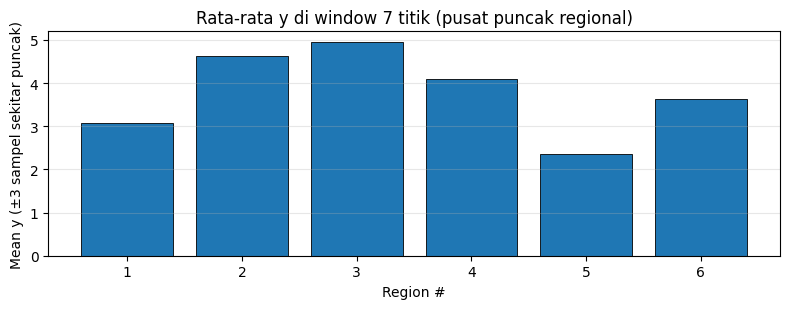

In [22]:
# cell 5
"""
Per region Schmitt: puncak regional = argmax(y) dalam array region.

Rata-rata y dihitung dari hingga 7 sampel berurutan yang berpusat di puncak:
indeks j-3 … j+3 (dalam koordinat region), dipotong ke [0, len-1] jika region pendek.
"""

import numpy as np
import matplotlib.pyplot as plt

# --- bangkit sinyal + region (sama seperti cell 4) ---
A_max = 5.0
T = 2.0
fs = 1000
n_cycles = 8
n_cycles = int(np.clip(n_cycles, 7, 10))
f0 = n_cycles / T
dt = 1.0 / fs
t = np.arange(0.0, T, dt)

f_env = 0.6
envelope = (A_max / 2) * (1 + np.sin(2 * np.pi * f_env * t))
f_fm = 0.5
df = 0.35 * f0
f_min = 0.15
f_inst = np.clip(f0 + df * np.sin(2 * np.pi * f_fm * t), f_min, None)
phi = np.cumsum(2 * np.pi * f_inst * dt)
y = envelope * np.sin(phi)
y_sig = np.where(y >= 0, y, 0.0)

TH = 2.0
HY = 0.05
TH_HIGH = TH + HY
TH_LOW = TH - HY

n = len(y_sig)
active = False
start_idx = 0
regions = []

if n > 0 and y_sig[0] >= TH_HIGH:
    active = True
    start_idx = 0

for i in range(n):
    yv = y_sig[i]
    if not active:
        if yv >= TH_HIGH:
            active = True
            start_idx = i
    else:
        if yv <= TH_LOW:
            regions.append(
                {
                    "i0": start_idx,
                    "i1": i,
                    "t": t[start_idx : i + 1].copy(),
                    "y": y_sig[start_idx : i + 1].copy(),
                }
            )
            active = False

if active:
    regions.append(
        {
            "i0": start_idx,
            "i1": n - 1,
            "t": t[start_idx:n].copy(),
            "y": y_sig[start_idx:n].copy(),
        }
    )

# --- rata-rata 7 titik (ideal) di sekitar puncak per region ---
region_means = []
print("Rata-rata y pada window ±3 sampel dari puncak regional (maks. 7 titik)\n")
for k, r in enumerate(regions, start=1):
    ya = np.asarray(r["y"])
    j = int(np.argmax(ya))
    lo = max(0, j - 3)
    hi = min(len(ya) - 1, j + 3)
    win = ya[lo : hi + 1]
    m = float(win.mean())
    region_means.append(m)
    n_win = len(win)
    note = " (7 titik penuh)" if n_win == 7 else f" (hanya {n_win} titik; puncak dekat tepi region)"
    print(f"Region {k}: j={j}, indeks window [{lo}, {hi}]{note}")
    print(f"  y = {np.array2string(win, precision=4, separator=', ')}")
    print(f"  mean = {m:.6f}\n")

print(f"Jumlah region: {len(region_means)}")
print(f"Mean per region: {region_means}")
if region_means:
    print(f"Rata-rata dari mean regional: {float(np.mean(region_means)):.6f}")

if region_means:
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.bar(np.arange(1, len(region_means) + 1), region_means, color="C0", edgecolor="k", linewidth=0.6)
    ax.set_xticks(np.arange(1, len(region_means) + 1))
    ax.set_xlabel("Region #")
    ax.set_ylabel("Mean y (±3 sampel sekitar puncak)")
    ax.set_title("Rata-rata y di window 7 titik (pusat puncak regional)")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Penjelasan: penangkapan region → puncak regional → rata-rata jendela 7 titik

Dokumen ini merangkum **alur logika** yang dipakai di notebook untuk sinyal **setelah rectifikasi** \(y = \max(y_{\text{asli}}, 0)\): dari **segmentasi region** dengan **Schmitt trigger (hysteresis)**, lalu **pencarian puncak** di dalam tiap region, hingga **rata-rata** pada **tujuh sampel** di sekitar puncak.

---

### 1. Konteks sinyal

- Sinyal yang dipakai adalah **nilai tidak negatif** (bagian negatif diganti nol), sehingga analisis di atas suatu **threshold positif** (misalnya **2**) masuk akal.
- Sinyal **diskrit**: tiap titik punya pasangan **\((t_i, y_i)\)** dengan jarak waktu \(\Delta t = 1/f_s\). Semua “naik / turun / puncak” dijelaskan dalam **urutan sampel**, bukan kurva kontinu matematis murni.

---

### 2. Mengapa pakai hysteresis (Schmitt), bukan satu garis di \(y = 2\) saja?

Kalau hanya **satu ambang** \(y = 2\), noise kecil atau osilasi di sekitar 2 bisa membuat sinyal **bolak-balik** melewati ambang dalam jarak waktu singkat → region **pecah–nyambung** (banyak segmen pendek yang tidak stabil).

**Schmitt** memakai **dua ambang**:

| Nama | Nilai (contoh TH = 2, HY = 0,05) | Peran |
|------|----------------------------------|--------|
| **TH_HIGH** | \(2 + 0{,}05 = 2{,}05\) | **Masuk** “mode region aktif” |
| **TH_LOW** | \(2 - 0{,}05 = 1{,}95\) | **Keluar** dari mode region aktif |

- **Mulai menangkap region** hanya setelah sinyal **cukup naik**: syarat **\(y \ge \text{TH\_HIGH}\)**. Artinya kita menuntut **komitmen** bahwa sinyal sudah **jelas di atas** pita sekitar threshold, bukan sekadar menyentuh 2 dari bawah dengan getaran kecil.
- **Menghentikan region** setelah sinyal **cukup turun**: syarat **\(y \le \text{TH\_LOW}\)**. Keluar juga memakai ambang **lebih rendah**, sehingga ada **dead band** antara 1,95 dan 2,05: setelah ON, sinyal boleh turun sedikit di atas 2 tanpa langsung dianggap OFF — baru OFF setelah benar-benar turun ke **1,95 ke bawah**.

Intinya: **asimetri** “naik pakai ambang tinggi, turun pakai ambang rendah” mengurangi **chatter** dan membuat **batas awal/akhir region** lebih stabil.

---

### 3. Apa yang disimpan dalam satu “region”?

Saat state **region capture aktif**, setiap sampel \((t, y)\) dalam interval tersebut dimasukkan ke dalam **array** `t` dan `y` untuk region itu.

- **Awal region**: indeks waktu pertama yang memenuhi **\(y \ge \text{TH\_HIGH}\)** (setelah sebelumnya tidak aktif).
- **Akhir region**: sampel **pertama** yang memenuhi **\(y \le \text{TH\_LOW}\)** saat sedang aktif; sampel penutup **ikut** disimpan (sesuai implementasi di sel kode).

Jumlah region **tidak tetap**; bergantung pada bentuk sinyal dan parameter AM/FM, durasi \(T\), serta nilai threshold dan hysteresis.

---

### 4. “Puncak regional” = apa?

Di dalam **satu region** (hanya melihat sampel di region itu), **puncak regional** didefinisikan sebagai sampel dengan **nilai \(y\) terbesar**:

- Indeks puncak: **`j = argmax(y)`** pada array region.
- Pada **satu bukit** bersih di atas ambang, ini biasanya sesuai intuisi **puncak** gelombang di interval tersebut.
- Pada data diskrit, ini adalah **maksimum** di region, bukan algoritma deteksi **semua** local maxima kontinu; jika bentuk region jarang aneh, `argmax` tetap satu titik **tertinggi**.

Dari puncak ini kita juga bisa membaca **\(t\)** puncak: **`t[j]`** pada array region.

---

### 5. Rata-rata “7 data”: 3 sebelum + puncak + 3 sesudah

Setelah **`j`** diketahui, kita ambil indeks **\(j-3, j-2, \ldots, j+3\)** — idealnya **7** titik berurutan **dalam koordinat region** (bukan selalu indeks global seluruh rekaman, kecuali jika nanti Anda petakan ulang ke indeks global).

- **Rata-rata window** = mean dari nilai \(y\) pada titik-titik itu.
- **Jika puncak dekat ujung region** (misalnya \(j < 3\) atau terlalu dekat ke ujung kanan), indeks **dipotong** ke rentang yang valid sehingga jumlah titik bisa **kurang dari 7**. Rata-rata tetap dihitung dari titik yang ada; di keluaran teks biasanya ada catatan jika jendela tidak penuh 7 sampel.

Interpretasi: kita ingin **ringkasan numerik** di sekitar puncak yang **tahan sedikit noise** (karena memakai beberapa sampel, bukan satu titik saja), tanpa harus memodelkan kurva kontinu.

---

### 6. Ringkasan alur (checklist)

1. Bangkitkan sinyal → rectifikasi \(y \leftarrow \max(y, 0)\).
2. **Schmitt**: OFF → ON saat \(y \ge \text{TH\_HIGH}\); ON → OFF saat \(y \le \text{TH\_LOW}\); isi region = sampel di antara keduanya (sesuai implementasi).
3. **Per region**: cari **`j = argmax(y)`**.
4. Ambil **hingga 7 sampel** di sekitar **`j`** (±3), hitung **mean** → **satu angka per region**.
5. (Opsional) Anda bisa juga melihat **daftar mean** tiap region atau **rata-rata dari mean-mean** tersebut sebagai ringkasan satu skalar untuk seluruh rekaman.

---

### 7. Catatan untuk pengembangan

- Jika nanti sinyal **bernois** di dalam region, pertimbangkan **median** di window 7 titik atau **hysteresis** lebih besar — trade-off antara stabilitas dan lebar region.
- Jika ingin **wajib tepat 7 titik**, Anda bisa **membuang** region yang terlalu pendek atau **memaksa** jendela ke indeks global (dengan definisi baru) — itu perubahan **spesifikasi**, bukan sekadar parameter kecil.


## Integral deret waktu gaya \(F(t)\): impuls, usaha, daya, dan energi

Catatan: di notebook, simbol \(y(t)\) dipakai untuk sinyal; di bagian ini \(y(t)\) **dibaca sebagai gaya** \(F(t)\) (satuan SI: **newton, N**), dan \(t\) dalam **detik (s)**. Data riil biasanya **diskrit** dengan langkah \(\Delta t = 1/f_s\).

---

### 1. Integral gaya terhadap waktu: **impuls**

Definisi kontinu:

\[
J = \int_{t_1}^{t_2} F(t)\,dt .
\]

- **Dimensi / satuan:** **N·s** = **kg·m/s** (sama dimensi dengan **momentum**).
- **Interpretasi fisika (klasik):** untuk **gaya resultan** \(F_{\text{res}}\) pada suatu benda,

\[
\int_{t_1}^{t_2} F_{\text{res}}\,dt = \Delta p = p(t_2) - p(t_1),
\]

yaitu **perubahan momentum** benda pada interval \([t_1, t_2]\) (**teorema impuls–momentum**).

**Pada data diskrit** (sampel \(F_i \approx F(t_i)\), langkah waktu \(\Delta t\)):

\[
J \approx \sum_i F_i\,\Delta t
\]

(atau trapesium / Simpson untuk pendekatan lebih halus). Ini **bukan** energi dan **bukan** usaha; besaran yang muncul adalah **impuls**.

---

### 2. **Usaha** (*work*): gaya terhubung dengan **perpindahan**, bukan hanya waktu

Definisi umum (3D):

\[
W = \int_C \vec{F} \cdot d\vec{x}.
\]

- Usaha mengukur seberapa besar gaya “bekerja” **sepanjang lintasan** \(C\): masuk **hasil kali titik** \(\vec{F} \cdot d\vec{x}\).
- **Satuan SI:** **joule (J)** = **N·m**.

**Kasus 1D sederhana:** jika \(\vec{F}\) sejajar dengan perpindahan dan arah tetap, sering ditulis \(W = \int F\,dx\).  
Jika \(F\) konstan dan perpindahan skalar \(s\) sejajar gaya: \(W = F\,s\).

**Hubungan dengan energi (teorema usaha–energi kinetik, partikel / translasi):**

\[
W_{\text{res}} = \Delta K = \frac{1}{2}m v_2^2 - \frac{1}{2}m v_1^2,
\]

dengan \(W_{\text{res}}\) = usaha oleh **gaya resultan** pada benda massa \(m\). Jadi **usaha** mengubah **energi kinetik** (dalam model ini; ada juga potensial, disipasi, dll. pada sistem nyata).

**Penting:** dari **hanya** deret \(F(t)\) **tanpa** informasi posisi/perpindahan \(x(t)\), Anda **tidak bisa** memulihkan usaha \(W = \int F\,dx\) secara unik—karena \(dx = v\,dt\), secara formal \(W = \int F(t)\,v(t)\,dt\). Jadi butuh juga **kecepatan** (atau posisi) sepanjang waktu, kecuali Anda punya model kinematik lain.

---

### 3. **Daya** (*power*): laju usaha (atau laju energi)

Definisi umum:

\[
P = \frac{dW}{dt}.
\]

Pada gerak translasi dengan gaya dan kecepatan:

\[
P = \vec{F} \cdot \vec{v}.
\]

- **Satuan SI:** **watt (W)** = **J/s** = **N·m/s**.
- **Bukan** “gaya × jarak”; yang muncul bersama gaya di sini adalah **kecepatan** (laju perpindahan), bukan jarak total.

Daya juga dapat ditulis sebagai turunan energi terhadap waktu, \(P = dE/dt\), bila \(E\) adalah energi suatu reservoir atau benda yang relevan dengan model Anda.

---

### 4. Ringkasan perbandingan (gaya sebagai \(F(t)\))

| Besaran | Rumus inti (kontinu) | “Butuh” selain \(F(t)\)? |
|--------|----------------------|---------------------------|
| **Impuls** \(J\) | \(\int F\,dt\) | Hanya \(F(t)\) + rentang waktu (untuk integral numerik). |
| **Usaha** \(W\) | \(\int F\,dx = \int F v\,dt\) | Perlu \(x(t)\) atau \(v(t)\) (atau model yang mengaitkan keduanya). |
| **Daya** \(P\) | \(dW/dt = Fv\) (1D sejajar) | Untuk \(Fv\): perlu \(v(t)\); atau \(P\) dari laju perubahan energi. |
| **Energi** \(E\) | Bentuk bergantung (kinetik, potensial, …) | Tidak ditentukan hanya oleh satu integral \(\int F\,dt\). |

---

### 5. Diskritisasi dan “region” deteksi

Jika Anda mengintegralkan \(F(t)\) **hanya** dari \(t_{\text{awal}}\) sampai \(t_{\text{akhir}}\) suatu **region** (misalnya dari algoritma Schmitt pada sinyal sensor):

- Hasil \(\sum F_i \Delta t\) pada interval itu = **impuls** pada interval tersebut (pendekatan numerik).
- Itu **tidak otomatis** sama dengan “usaha pada region” kecuali Anda juga punya **perpindahan** atau **kecepatan** yang konsisten dengan definisi usaha yang Anda maksud.

Batas region dari threshold adalah **keputusan pengolahan sinyal**; besaran fisika (impuls, usaha, dll.) tetap mengikuti **definisi integral** di atas, bukan mengikuti nama “region” di kode.

---

### 6. Catatan sensor dan gaya resultan

- Sensor gaya sering mengukur **komponen** atau **reaksi** pada satu titik; **gaya resultan** pada benda utuh bisa beda (ada gaya lain, gesekan, dsb.).
- Offset, drift, dan filter digital mengubah interpretasi integral; kalibrasi dan model sistem diperlukan sebelum menyamakan \(\int y\,dt\) dengan \(\Delta p\) teoretis.

---

**Inti:** \(\int F\,dt\) → **impuls / perubahan momentum** (jika \(F\) resultan). **Usaha** membutuhkan **perpindahan** (\(\int F\,dx\) atau \(\int Fv\,dt\)). **Daya** membutuhkan **laju** (\(dW/dt\), atau \(F\cdot v\)). **Energi** dihubungkan lewat teorema usaha–energi atau bentuk energi spesifik, tidak cukup dari satu integral waktu gaya saja tanpa konteks kinematik.
